In [1]:
## This is a series of examples demonstrating the use of the icanswim/cosmosis repo 
## for data science and machine learning projects.
## This repo is intended to be used as the boiler plate for data science and machine learning projects.
## See the icanswim/qchem repo for a demonstration of the use of this (icanswim/cosmosis) repo.

In [1]:
# imports for all the cosmosis experiments

from model import tv_model, IdentityModel, GPT, FFNet
from learning import Learn, Selector, Metric
from dataset import CDataset, SKDS, TVDS, ExampleDataset
from dataset import ImageDatasetStats, AsTensor, SqueezeN, SqueezeT
from dataset import Pad1d, Encode, Reshape, PrintArray

from torch.optim import Adam
from torch.nn import MSELoss, CrossEntropyLoss
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import transforms

import numpy as np

logger = Metric.setup_logging(log_name='cosmosis_experiment', log_dir='./data')


2026-04-17 13:40:01,199 [cosmosis_experiment] INFO: cosmosis_experiment logging initialized at: ./data/cosmosis_experiment_20260417_134001.log


In [ ]:
# cosmosis blank parameters

vocab_feature_3 = ExampleDataset.vocab['feature_3']
ds_param = {'train_param': {'input_dict': {'X': ['feature_1','feature_2'],
                                           'feature_3': ['feature_3']},
                            'transforms': {'feature_1': [ExampleTransform(10), AsTensor()],
                                           'feature_2': [Reshape(-1), AsTensor()],
                                           'feature_3': [Pad1d(5), Encode(vocab_feature_3), AsTensor()]},
                            'boom': 'bang'}}

model_param = {'some_param': 128,
               'y': 'feature_3',
               'embed_param': {'feature_3': (voc,vec,padding_idx,trainable),
                               'some_param': True,
                               'flatten': True}} 
                                       
metric_param = {'subset': .2, # create a random subset
                 'report_interval': 10,
                 'last_n': 10, # display the last_n examples at the end of each report_interval
                 'log_plot': True,
                 'min_lr': .005} # break if learning rate falls below                        
             
opt_param = {'lr': 0.01}

crit_param = {}

sample_param = {'set_seed': 88,
                'splits': (.7,.15)}

sched_param = {'factor': .5, 
               'patience': 2,
               'cooldown': 2}

learn = Learn([DS], 
              Model,
              Metric=Metric,
              Sampler=Selector, 
              Optimizer=Optimizer, 
              Scheduler=ReduceLROnPlateau, 
              Criterion=LossFunction,
              model_param=model_param, ds_param=ds_param, sample_param=sample_param,
              opt_param=opt_param, sched_param=sched_param, crit_param=crit_param,
              metric_param=metric_param, 
              batch_size=12, epochs=1, gpu=True)


In [ ]:
# CDataset class exploration

class ExampleTransform():
    def __init__(self, num):
        self.num = num
        
    def __call__(self, arr):
        return np.add(arr, self.num)


class ExampleDataset(CDataset):
    # zero is the vocab for the padding index 
    vocab = {'feature_4': {'a': 1,'b': 2,'c': 3,'d': 4, '0': 0},
             'feature_3': {'z1': 1, 'y1': 2, 'x1': 3, '0': 0},
             'feature_6': {'e': 1, 'f': 2, 'g': 3, '0': 0}}
    
    def load_data(self, boom='bust'):
        
        datadic = {1: {'feature_1': np.asarray([.04]),
                       'feature_2': np.asarray([[.02,.03],[.04,.05]]),
                       'feature_3': np.asarray(['z1']),
                       'feature_4': np.asarray(['c','c','d']),
                       'feature_5': np.asarray([1.1]),
                       'feature_6': np.asarray(['e','f','g'])},
                   2: {'feature_1': np.asarray([.03]),
                       'feature_2': np.asarray([[.1,.2],[.3,.4]]),
                       'feature_3': np.asarray(['x1','z1','y1']),
                       'feature_4': np.asarray(['d','a','d']),
                       'feature_5': np.asarray([1.2]),
                       'feature_6': np.asarray(['f','f','g'])}}
        
        print(boom)
        return datadic
    
vocab_feature_3 = ExampleDataset.vocab['feature_3']
vocab_feature_4 = ExampleDataset.vocab['feature_4']
vocab_feature_6 = ExampleDataset.vocab['feature_6']
ds_param = {'train_param': {'input_dict': {
                                           'X2': ['feature_1','feature_2'], 
                                           'X3': ['feature_2'],
                                           'embed_3': ['feature_3'],
                                           'embed_4': ['feature_4'],
                                           'target': ['feature_5'],
                                            },
                            'transforms': {'feature_1': [ExampleTransform(10), Reshape((-1)), AsTensor()],
                                           'feature_2': [Reshape((-1)), AsTensor()],
                                           'feature_3': [Pad1d(5), Encode(vocab_feature_3), AsTensor()],
                                           'feature_4': [Pad1d(5), Encode(vocab_feature_4), AsTensor()],
                                           'feature_5': [AsTensor()],
                                           'feature_6': [Pad1d(5), Encode(vocab_feature_6), AsTensor()]},
                            'boom': 'bang'}}
    
ed = ExampleDataset(**ds_param['train_param'])
print('ed[1]: ', ed[1])

model_param = {'device': 'cpu',
               'X': ['X2', 'X3'],
               'y': 'target',
               'embed_param': {'embed_3': (4,8,0,False),
                               'embed_4': (5,8,0,False),
                               'flatten': True}
              }

im = IdentityModel(model_param)
print(im)
print('embedding_layer: ', im.embedding_layer)

out = im(ed[1])
print('out: ', out)
print('out.shape: ', out.shape) # (1+4+4+5*8+5*8) = 89


bang
ed[1]:  {'X2': tensor([10.0400,  0.0200,  0.0300,  0.0400,  0.0500], dtype=torch.float64), 'X3': tensor([0.0200, 0.0300, 0.0400, 0.0500], dtype=torch.float64), 'embed_3': tensor([1, 0, 0, 0, 0]), 'embed_4': tensor([3, 3, 4, 0, 0]), 'target': tensor([1.1000], dtype=torch.float64)}
IdentityModel(
  (layers): ModuleList(
    (0): Identity()
  )
)
embedding_layer:  {'embed_3': Embedding(4, 8, padding_idx=0), 'embed_4': Embedding(5, 8, padding_idx=0)}
out:  tensor([10.0400,  0.0200,  0.0300,  0.0400,  0.0500,  0.0200,  0.0300,  0.0400,
         0.0500, -0.7227,  2.2016, -0.4239, -0.4435, -0.9025,  0.1189,  0.2033,
        -0.6159,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000, -0.1765, -1.4561,  0.2662,  1.2147,  1.83

In [3]:
# SKDS regression dataset sklearn wrapper
                            
ds_param = {'train_param': {'input_dict': {'model_input': ['X'],
                                           'y': ['y']},
                            'dataset': 'make_regression',
                            'sk_param': {'n_samples': 100,
                                         'n_features': 5},
                            'features_dtype': 'float32',
                            'targets_dtype': 'float32'}}

sk = SKDS(**ds_param['train_param'])

sk[1]


{'model_input': array([ 0.41050902, -1.5570194 ,  0.22915639, -0.82822526,  0.09637836],
       dtype=float32),
 'y': array([-93.842354], dtype=float32)}

In [4]:
# SKDS classification dataset sklearn wrapper

ds_param = {'train_param': {'input_dict': {'X': ['X'],
                                           'y': ['y']},
                            'features_dtype': 'float32',
                            'targets_dtype': 'int64',
                            'transforms': {'y': [AsTensor()],
                                           'X': [AsTensor()]},
                            'dataset': 'make_classification',
                            'sk_param': {'n_samples': 1000,
                                         'n_features': 30,
                                         'n_informative': 20,
                                         'n_clusters_per_class': 3,
                                         'flip_y': 0.05,
                                         'class_sep': 0.1,
                                         'n_classes': 4}}}

sk = SKDS(**ds_param['train_param'])

print(sk[1])


{'X': tensor([-3.3461,  1.3082,  0.8387,  0.1311, -0.8118,  2.1491, -1.7899,  0.3053,
         0.2163, -1.8393,  0.1108,  2.7955,  0.1227, -1.8599,  0.0176,  2.4232,
        -4.7408, -1.7781,  2.1304,  0.9265,  1.5437,  0.8591,  7.8399, -1.2029,
        -2.9081, -0.1579, -1.7141,  2.7417,  1.1746, -0.4332]), 'y': tensor([1])}


In [5]:
# TVDS dataset torchvision image wrapper

ds_param = {'train_param': {'input_dict': {'features': ['images'],
                                           'y': ['labels']},
                            'dataset': 'MNIST',
                            'tv_param': {'root': './data/',
                                         'train': True,
                                         'download': True,
                                         'transform': transforms.Compose([transforms.Resize(224)]),
                                         'target_transform': None}}}

tvds = TVDS(**ds_param['train_param'])
tvds[1]


100.0%
100.0%
100.0%
100.0%


{'image': <PIL.Image.Image image mode=L size=224x224>, 'y': 0}

In [6]:
# TVDS dataset torchvision image wrapper with transforms and PIL stats

ds_param={'dataset': 'MNIST',
          'tv_param': {'root': './data/',
                       'train': True,
                       'download': True,
                       'transform': transforms.Compose([transforms.Resize(224)]),
                       'target_transform': None}}

tvds = TVDS(**ds_param)
ids = ImageDatasetStats(tvds)

print('mean: ', ids.stats.mean)
print('stddev: ', ids.stats.stddev)

# mean: 33.3/255 = .13
# stddev: 73.7/255 = .29

creating torch vision MNIST dataset...
CDataset created...
images to process: 60000
images processed: 10000
images processed: 20000
images processed: 30000
images processed: 40000
images processed: 50000
images processed: 60000
mean: [33.33091590401786], stddev: [73.70246726596685]
mean:  [33.33091590401786]
stddev:  [73.70246726596685]


In [2]:
# SKDS dataset sklearn wrapper with Metric from sklearn and a FFNet cosmosis model

from model import FFNet
from learning import Learn, Selector, Metric
from dataset import SKDS

from torch.optim import Adam
from torch.nn import MSELoss
from torch.optim.lr_scheduler import ReduceLROnPlateau



model_param = {'in_channels': 1024, 
                'hidden': 512, 
                'out_channels': 1, 
                'model_name': 'funnel',
                'activation': 'GELU'}

ds_param = {'train_param': {'input_dict': {'X': ['X'],
                                           'y': ['y']},
                            'transforms': {'X': [AsTensor('float32')],
                                           'y': [AsTensor('float32')]},
                            'dataset': 'make_regression',
                            'sk_param': {'n_samples':20000,
                                         'n_features': 1024,
                                         'n_informative': 800}}}
             
metric_param = {'report_interval': 1,
                 'last_n': 5,
                 'min_lr': .00125} #break if learning rate falls below                        
             
opt_param = {'lr': 0.01}

crit_param = {'reduction': 'sum'}

sample_param = {'set_seed': 88,
                'splits': (.7,.15)}

sched_param = {'factor': .5, 
               'patience': 2,
               'cooldown': 2}

learn = Learn([SKDS], 
              FFNet,
              Metric=Metric,
              Sampler=Selector, 
              Optimizer=Adam, 
              Scheduler=ReduceLROnPlateau, 
              Criterion=MSELoss,
              model_param=model_param, ds_param=ds_param, sample_param=sample_param,
              opt_param=opt_param, sched_param=sched_param, crit_param=crit_param,
              metric_param=metric_param, 
              batch_size=512, epoch=5, gpu=True)

learn.run_experiment()


2026-04-17 13:40:10,714 [dataset] INFO: creating scikit learn make_regression dataset...
2026-04-17 13:40:11,461 [dataset] INFO: CDataset.__init__ created...
2026-04-17 13:40:11,482 [model] INFO: CModel.FFNet model loaded...
2026-04-17 13:40:11,484 [model] INFO: CModel.init_weights applying _init_weights...
2026-04-17 13:40:11,492 [model] INFO: CModel.__init__FFNet model loaded...
2026-04-17 13:40:11,493 [model] INFO: CModel.get_num_params number of model parameters: 1251585
2026-04-17 13:40:11,494 [learning] INFO: learn.__init__ initializing new model FFNet...
2026-04-17 13:40:11,496 [learning] WARNING: learn.__init__ gpu not available. on cpu...
2026-04-17 13:40:11,497 [learning] INFO: learn.__init__ learner ready: MSELoss, Adam, Scheduler: ReduceLROnPlateau
2026-04-17 13:40:12,850 [learning] INFO: learn.report epoch: 1 elapsed: 0:00:01.377892
2026-04-17 13:40:12,852 [learning] INFO: metric.report last 5 predictions: tensor([[ -61.6157],
        [ 101.1955],
        [ 155.2383],
    

{'training job': 'completed',
 'total_time': datetime.timedelta(seconds=6, microseconds=770707),
 'test_loss': [181505.39375]}

In [3]:
# SKDS dataset with sklearn Metric and FFNet model

model_param = {'in_channels': 256, 
               'hidden': 128, 
               'out_channels': 4,
               'model_name': 'funnel'}

ds_param = {'train_param': {'input_dict': {'X': ['X'],
                                           'y': ['y']},
                            'transforms': {'y': [AsTensor('int64'), SqueezeT()],
                                           'X': [AsTensor('float32')]},
                            'dataset': 'make_classification',
                            'sk_param': {'n_samples': 10000,
                                         'n_features': 300,
                                         'n_informative': 200,
                                         'n_redundant': 5,
                                         'n_repeated': 5,
                                         'n_clusters_per_class': 5,
                                         'flip_y': 0.05,
                                         'class_sep': 0.05,
                                         'n_classes': 4}}}
                                     
metric_param = {'report_interval': 1,
                 'metric_name': 'accuracy_score', # sklearn
                 'metric_param': {},
                 'last_n': 3}

opt_param = {'lr': 0.01}

crit_param = {}

sample_param = {'set_seed': 88,
                 'splits': (.7,.15)}

sched_param = {'factor': .5,
               'patience': 2,
               'cooldown': 1}

learn = Learn([SKDS], 
              FFNet, 
              Sampler=Selector,
              Metric=Metric,
              Optimizer=Adam, 
              Scheduler=ReduceLROnPlateau, 
              Criterion=CrossEntropyLoss,
              model_param=model_param, ds_param=ds_param, 
              sample_param=sample_param, opt_param=opt_param, 
              sched_param=sched_param, crit_param=crit_param,
              metric_param=metric_param,
              adapt=(300,256,.2), batch_size=128, epoch=5, num_workers=0, 
              save_model='demo_model', gpu=False)

learn.run_experiment()


2026-04-17 13:40:24,059 [dataset] INFO: creating scikit learn make_classification dataset...
2026-04-17 13:40:24,311 [dataset] INFO: CDataset.__init__ created...
2026-04-17 13:40:24,317 [model] INFO: CModel.FFNet model loaded...
2026-04-17 13:40:24,318 [model] INFO: CModel.init_weights applying _init_weights...
2026-04-17 13:40:24,320 [model] INFO: CModel.__init__FFNet model loaded...
2026-04-17 13:40:24,321 [model] INFO: CModel.get_num_params number of model parameters: 79620
2026-04-17 13:40:24,322 [learning] INFO: learn.__init__ initializing new model FFNet...
2026-04-17 13:40:24,324 [learning] INFO: learn.__init__ running model on cpu...
2026-04-17 13:40:24,325 [learning] INFO: learn.__init__ learner ready: CrossEntropyLoss, Adam, Scheduler: ReduceLROnPlateau
2026-04-17 13:40:24,813 [learning] INFO: learn.report epoch: 1 elapsed: 0:00:00.497914
2026-04-17 13:40:24,815 [learning] INFO: metric.report last 3 predictions: tensor([[-0.0398, -1.6801,  0.3801,  0.5457],
        [ 0.8249, 

{'training job': 'completed',
 'total_time': datetime.timedelta(seconds=2, microseconds=390665),
 'test_loss': [0.01081242420795289],
 'accuracy_score': 0.2578125}

In [4]:
# SKDS dataset with torcheval Metric and FFNet model

model_param = {'in_channels': 256, 
               'hidden': 128, 
               'out_channels': 4,
               'model_name': 'funnel'}

ds_param = {'train_param': {'input_dict': {'X': ['X'],
                                           'y': ['y']},
                            'transforms': {'y': [AsTensor('int64'), SqueezeT()],
                                           'X': [AsTensor('float32')]},
                            'dataset': 'make_classification',
                            'sk_param': {'n_samples': 100000,
                                         'n_features': 256,
                                         'n_informative': 200,
                                         'n_redundant': 5,
                                         'n_repeated': 5,
                                         'n_clusters_per_class': 5,
                                         'flip_y': 0.05,
                                         'class_sep': 0.05,
                                         'n_classes': 4}}}
                                     
metric_param = {'report_interval': 1,
                 'metric_name': 'multiclass_accuracy', # torcheval
                 'metric_param': {'num_classes': 4}}

opt_param = {'lr': 0.01}

crit_param = {}

sample_param = {'set_seed': 88,
                 'splits': (.7,.15)}

sched_param = {'factor': .5,
               'patience': 2,
               'cooldown': 1}

learn = Learn([SKDS], 
              FFNet, 
              Sampler=Selector,
              Metric=Metric,
              Optimizer=Adam, 
              Scheduler=ReduceLROnPlateau, 
              Criterion=CrossEntropyLoss,
              model_param=model_param, ds_param=ds_param, 
              sample_param=sample_param, opt_param=opt_param, 
              sched_param=sched_param, crit_param=crit_param,
              metric_param=metric_param,
              batch_size=256, epoch=5, num_workers=0, gpu=False,
              save_model='demo_model')

learn.run_experiment()


2026-04-17 13:42:37,029 [dataset] INFO: creating scikit learn make_classification dataset...
2026-04-17 13:42:38,573 [dataset] INFO: CDataset.__init__ created...
2026-04-17 13:42:38,609 [model] INFO: CModel.FFNet model loaded...
2026-04-17 13:42:38,611 [model] INFO: CModel.init_weights applying _init_weights...
2026-04-17 13:42:38,613 [model] INFO: CModel.__init__FFNet model loaded...
2026-04-17 13:42:38,614 [model] INFO: CModel.get_num_params number of model parameters: 79620
2026-04-17 13:42:38,615 [learning] INFO: learn.__init__ initializing new model FFNet...
2026-04-17 13:42:38,617 [learning] INFO: learn.__init__ running model on cpu...
2026-04-17 13:42:38,618 [learning] INFO: learn.__init__ learner ready: CrossEntropyLoss, Adam, Scheduler: ReduceLROnPlateau
2026-04-17 13:42:41,521 [learning] INFO: learn.report epoch: 1 elapsed: 0:00:02.914218
2026-04-17 13:42:41,524 [learning] INFO: metric.report last 1 predictions: tensor([[0.1033, 0.1308, 0.1062, 0.1005]])
2026-04-17 13:42:41,5

{'training job': 'completed',
 'total_time': datetime.timedelta(seconds=15, microseconds=11235),
 'test_loss': [0.005409682193642546],
 'multiclass_accuracy': 0.27384158968925476}

In [5]:
# inference with SKDS dataset and FFNet model

model_param = {'in_channels': 256, 
               'hidden': 128, 
               'out_channels': 4, 
               'model_name': 'funnel'}

ds_param = {'train_param': {'input_dict': {'X': ['X']},
                            'transforms': {'X': [AsTensor('float32')]},
                            'dataset': 'make_classification',
                            'sk_param': {'n_samples': 100000,
                                         'n_features': 256,
                                         'n_informative': 200,
                                         'n_redundant': 5,
                                         'n_repeated': 5,
                                         'n_clusters_per_class': 5,
                                         'flip_y': 0.05,
                                         'class_sep': 0.05,
                                         'n_classes': 4}}}
                                     
learn = Learn([SKDS], 
              FFNet, 
              Sampler=Selector,
              Metric=Metric,
              Optimizer=Adam, 
              Scheduler=ReduceLROnPlateau, 
              Criterion=None, # no criterion implies inference
              model_param=model_param, ds_param=ds_param, gpu=False,
              batch_size=128, epoch=2, load_model='demo_model')

learn.run_experiment()


2026-04-17 13:43:09,749 [dataset] INFO: creating scikit learn make_classification dataset...
2026-04-17 13:43:11,341 [dataset] INFO: CDataset.__init__ created...
2026-04-17 13:43:11,372 [model] INFO: CModel.FFNet model loaded...
2026-04-17 13:43:11,373 [model] INFO: CModel.init_weights applying _init_weights...
2026-04-17 13:43:11,375 [model] INFO: CModel.__init__FFNet model loaded...
2026-04-17 13:43:11,378 [model] INFO: CModel.get_num_params number of model parameters: 79620
2026-04-17 13:43:11,384 [learning] INFO: learn.__init__ model loaded from: demo_model.pth
2026-04-17 13:43:11,386 [learning] INFO: learn.__init__ model loaded: FFNet
2026-04-17 13:43:11,388 [learning] INFO: learn.__init__ running model on cpu...
2026-04-17 13:43:11,389 [learning] INFO: learn.__init__ inference engine ready...
2026-04-17 13:43:11,420 [learning] INFO: learn.infer predictions: [[-1.34392912e-02  1.70212276e-02  9.41257831e-03 -2.97578890e-03]
 [ 8.33076145e-03  1.52047658e-02  4.56684865e-02  2.8410

{'learn.infer predictions': array([[-1.34392912e-02,  1.70212276e-02,  9.41257831e-03,
         -2.97578890e-03],
        [ 8.33076145e-03,  1.52047658e-02,  4.56684865e-02,
          2.84105502e-02],
        [ 3.71946543e-02,  7.57157430e-02,  5.09677678e-02,
          1.32617518e-01],
        [-1.34392912e-02,  1.70212276e-02,  9.41257831e-03,
         -2.97578890e-03],
        [-1.34392912e-02,  1.70212276e-02,  9.41257831e-03,
         -2.97578890e-03],
        [-4.84043173e-02, -3.49102728e-03, -2.73611359e-02,
         -3.40395570e-02],
        [-1.34392912e-02,  1.70212276e-02,  9.41257831e-03,
         -2.97578890e-03],
        [-1.34392912e-02,  1.70212276e-02,  9.41257831e-03,
         -2.97578890e-03],
        [-1.34392912e-02,  1.70212276e-02,  9.41257831e-03,
         -2.97578890e-03],
        [-7.61050731e-04,  2.94123553e-02,  2.07478534e-02,
          2.37698816e-02],
        [-1.34392912e-02,  1.70212276e-02,  9.41257831e-03,
         -2.97578890e-03],
        [ 1.2436

creating torch vision CIFAR10 dataset...
Files already downloaded and verified
CDataset created...
creating torch vision CIFAR10 dataset...
Files already downloaded and verified
CDataset created...
torchvision model resnet18 loaded...
running model on gpu...

.....................

total elapsed time: 0:00:32.793544
epoch: 7
y_pred last 5 values:
 tensor([[ 4.6489, -1.5626,  0.0247, -3.5520, -1.7317, -3.0708, -4.8536, -3.1804,
          3.6979, -0.2398],
        [-1.8392,  0.9998, -0.6329, -0.8054, -1.6400, -2.1537,  4.4592, -2.8383,
         -4.5012,  1.2006],
        [ 0.1603, -2.8240,  1.2148,  0.6084,  0.6152,  0.7768, -1.1646,  0.2847,
         -1.3415, -1.8729],
        [-0.6239, -0.6595, -0.6338,  0.1475, -1.2008, -0.6719, -0.6915,  1.0208,
         -3.1468,  1.6852],
        [ 2.5280,  0.8593, -0.6672, -2.5827, -1.3159, -2.9824, -3.0674, -2.4828,
          2.4518,  0.0668]], device='cuda:0')
y last 5 values:
 tensor([8, 6, 7, 7, 0], device='cuda:0')
train loss: 1.35725820732116

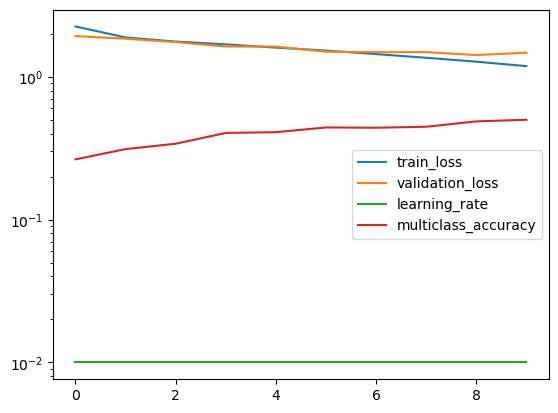

In [ ]:
# TVDS dataset torchvision wrapper (TVDS) with transforms and tv_model torchvision model wrapper

model_param = {'model_name': 'resnet18',
               'in_channels': 3,
               'tv_param': {'num_classes': 10}}

ds_param={'train_param': {'dataset': 'CIFAR10',
                          'tv_param': {'root': './data/',
                                       'train': True,
                                       'download': True,
                                       'transform': transforms.Compose([
                                                           transforms.RandomRotation(10),
                                                           transforms.Resize(64),
                                                           transforms.ToTensor()]),
                                       'target_transform': None,
                                       'download': True}},
           'test_param': {'dataset': 'CIFAR10',
                          'tv_param': {'root': './data/',
                                       'train': False,
                                       'download': True,
                                       'transform': transforms.Compose([
                                                         transforms.Resize(64),
                                                         transforms.ToTensor()]),
                                       'target_transform': None,
                                       'download': True}}}

metric_param = {'report_interval': 30,
                 'log_plot': True,
                 'metric_name': 'multiclass_accuracy', # torcheval
                 'metric_param': {'num_classes': 10}}

opt_param = {'lr': 0.01}

crit_param = {'reduction': 'sum'}

sample_param = {'set_seed': 88,
                'splits': (.8,),
                'subset': .1}

sched_param = {'factor': .5,
               'patience': 1,
               'cooldown': 1}

learn = Learn([TVDS,TVDS], 
              tv_model, 
              Selector, 
              Optimizer=Adam, 
              Scheduler=ReduceLROnPlateau, 
              Criterion=CrossEntropyLoss, 
              model_param=model_param, ds_param=ds_param, sample_param=sample_param, 
              opt_param=opt_param, sched_param=sched_param, crit_param=crit_param,
              metric_param=metric_param, 
              batch_size=16, epochs=10)

creating torch vision CIFAR10 dataset...
CDataset created...
creating torch vision CIFAR10 dataset...
CDataset created...
torchvision model resnext50_32x4d loaded...
running model on gpu...

.....................

total elapsed time: 0:06:00.419056
epoch: 5
y_pred last 5 values:
 tensor([[-1.3353, -3.1462,  0.7990,  1.0110,  1.0952,  0.7468,  1.1485,  1.0362,
         -3.2205, -1.8971],
        [ 0.9360, -1.2769,  0.1045, -0.7608, -0.1858, -0.8945, -1.3079, -0.5278,
         -0.1922, -0.9544],
        [-1.9157,  1.1493, -1.2919,  0.7091, -0.5229,  1.0131, -0.2887,  0.7112,
         -2.3873,  0.9186],
        [ 0.4446,  1.1960, -0.9554, -1.0802, -0.6246, -1.0012, -2.2384, -0.7762,
         -0.1476,  0.4338],
        [-0.9821, -1.7855, -0.1470, -0.1502,  0.0683, -0.8715,  0.2080,  1.5701,
         -2.2944,  0.0584]], device='cuda:0')
y last 5 values:
 tensor([6, 5, 1, 7, 7], device='cuda:0')
train loss: 1.85066233253479, val loss: 1.8485319095273172
lr: 0.01
multiclass_accuracy train sco

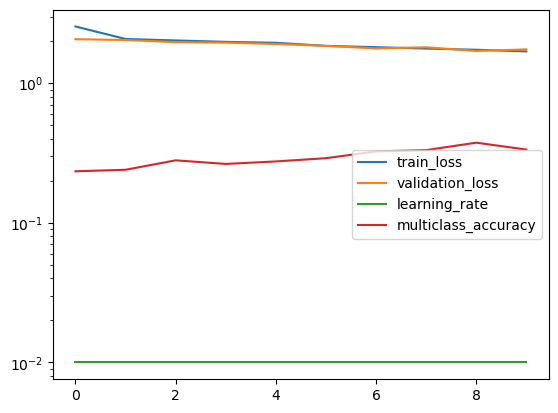

In [ ]:
# TVDS dataset torchvision wrapper (TVDS) with transforms and tv_model torchvision model wrapper

model_param = {'model_name': 'resnext50_32x4d',
               'in_channels': 3,
               'tv_param': {'num_classes': 10}}

ds_param={'train_param': {'dataset': 'CIFAR10',
                          'tv_param': {'root': './data/',
                                       'train': True,
                                       'transform': transforms.Compose([
                                                    transforms.RandomRotation(10),
                                                    transforms.Resize(256),
                                                    transforms.ToTensor()]),
                                       'target_transform': None}},
           'test_param': {'dataset': 'CIFAR10',
                          'tv_param': {'root': './data/',
                                       'train': False,
                                       'transform': transforms.Compose([
                                                    transforms.Resize(256),
                                                    transforms.ToTensor()]),
                                       'target_transform': None}}}

metric_param = {'report_interval': 300,
                 'log_plot': True,
                 'metric_name': 'multiclass_accuracy', # torcheval
                 'metric_param': {'num_classes': 10}}

opt_param = {'lr': 0.01}

crit_param = {'reduction': 'sum'}

sample_param = {'set_seed': 88,
                'splits': (.8,),
                'subset': .1}

sched_param = {'factor': .5,
               'patience': 2,
               'cooldown': 1}

l = Learn([TVDS,TVDS], 
          tv_model, 
          Selector, 
          Optimizer=Adam, 
          Scheduler=ReduceLROnPlateau, 
          Criterion=CrossEntropyLoss, 
          model_param=model_param, ds_param=ds_param, 
          sample_param=sample_param, opt_param=opt_param, 
          sched_param=sched_param, crit_param=crit_param,
          metric_param=metric_param,
          batch_size=16, epochs=10)